## Data Analysis Blinkit Project Using Pyhton

In [56]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [57]:
df=pd.read_csv("C:/Users/vaibh/Downloads/blinkit_data.csv")
df

,Item Fat Content,Item Identifier,Item Type,Outlet Establishment Year,Outlet Identifier,Outlet Location Type,Outlet Size,Outlet Type,Item Visibility,Item Weight,Sales,Rating
0,Regular,FDX32,Fruits and Vegetables,2012,OUT049,Tier 1,Medium,Supermarket Type1,0.100014,15.10,145.4786,5.0
1,Low Fat,NCB42,Health and Hygiene,2022,OUT018,Tier 3,Medium,Supermarket Type2,0.008596,11.80,115.3492,5.0
2,Regular,FDR28,Frozen Foods,2010,OUT046,Tier 1,Small,Supermarket Type1,0.025896,13.85,165.0210,5.0
3,Regular,FDL50,Canned,2000,OUT013,Tier 3,High,Supermarket Type1,0.042278,12.15,126.5046,5.0
4,Low Fat,DRI25,Soft Drinks,2015,OUT045,Tier 2,Small,Supermarket Type1,0.033970,19.60,55.1614,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...
8518,low fat,NCT53,Health and Hygiene,1998,OUT027,Tier 3,Medium,Supermarket Type3,0.000000,NaN,164.5526,4.0
8519,low fat,FDN09,Snack Foods,1998,OUT027,Tier 3,Medium,Supermarket Type3,0.034706,NaN,241.6828,4.0
8520,low fat,DRE13,Soft Drinks,1998,OUT027,Tier 3,Medium,Supermarket Type3,0.027571,NaN,86.6198,4.0
8521,reg,FDT50,Dairy,1998,OUT027,Tier 3,Medium,Supermarket Type3,0.107715,NaN,97.8752,4.0


In [58]:
df.head(10)

,Item Fat Content,Item Identifier,Item Type,Outlet Establishment Year,Outlet Identifier,Outlet Location Type,Outlet Size,Outlet Type,Item Visibility,Item Weight,Sales,Rating
0,Regular,FDX32,Fruits and Vegetables,2012,OUT049,Tier 1,Medium,Supermarket Type1,0.100014,15.10,145.4786,5.0
1,Low Fat,NCB42,Health and Hygiene,2022,OUT018,Tier 3,Medium,Supermarket Type2,0.008596,11.80,115.3492,5.0
2,Regular,FDR28,Frozen Foods,2010,OUT046,Tier 1,Small,Supermarket Type1,0.025896,13.85,165.0210,5.0
3,Regular,FDL50,Canned,2000,OUT013,Tier 3,High,Supermarket Type1,0.042278,12.15,126.5046,5.0
4,Low Fat,DRI25,Soft Drinks,2015,OUT045,Tier 2,Small,Supermarket Type1,0.033970,19.60,55.1614,5.0
5,low fat,FDS52,Frozen Foods,2020,OUT017,Tier 2,Small,Supermarket Type1,0.005505,8.89,102.4016,5.0
6,Low Fat,NCU05,Health and Hygiene,2011,OUT010,Tier 3,Small,Grocery Store,0.098312,11.80,81.4618,5.0
7,Low Fat,NCD30,Household,2015,OUT045,Tier 2,Small,Supermarket Type1,0.026904,19.70,96.0726,5.0
8,Low Fat,FDW20,Fruits and Vegetables,2000,OUT013,Tier 3,High,Supermarket Type1,0.024129,20.75,124.1730,5.0
9,Low Fat,FDX25,Canned,1998,OUT027,Tier 3,Medium,Supermarket Type3,0.101562,NaN,181.9292,5.0


In [59]:
df.shape


(8523, 12)

In [60]:
df.columns

Index(['Item Fat Content', 'Item Identifier', 'Item Type',
       'Outlet Establishment Year', 'Outlet Identifier',
       'Outlet Location Type', 'Outlet Size', 'Outlet Type', 'Item Visibility',
       'Item Weight', 'Sales', 'Rating'],
      dtype='str')

In [61]:
df.dtypes

Item Fat Content                 str
Item Identifier                  str
Item Type                        str
Outlet Establishment Year      int64
Outlet Identifier                str
Outlet Location Type             str
Outlet Size                      str
Outlet Type                      str
Item Visibility              float64
Item Weight                  float64
Sales                        float64
Rating                       float64
dtype: object

In [62]:
df["Item Fat Content"].unique()

<StringArray>
['Regular', 'Low Fat', 'low fat', 'LF', 'reg']
Length: 5, dtype: str

In [63]:
df["Item Fat Content"]=df["Item Fat Content"].replace({"LF":"Low Fat","low fat":"Low Fat","reg":"Regular"},inplace=True)

C:\Users\vaibh\AppData\Local\Temp\ipykernel_2968\2441516707.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df["Item Fat Content"]=df["Item Fat Content"].replace({"LF":"Low Fat","low fat":"Low Fat","reg":"Regular"},inplace=True)


In [64]:
df["Item Fat Content"].unique()

<StringArray>
['Regular', 'Low Fat']
Length: 2, dtype: str

In [65]:
total_sales=df["Sales"].sum()
avg_sales=df["Sales"].mean()
no_of_items_sold=df["Sales"].count()
avg_rating=df["Rating"].mean()

In [66]:
print(f"Total Sales: ${total_sales:,.1f}")
print(f"avg_sales: ${avg_sales:,.1f}")
print(f"no_of_items_sold: ${no_of_items_sold:,.1f}")
print(f"avg_rating: ${avg_rating:,.1f}")

Total Sales: $1,201,681.5
avg_sales: $141.0
no_of_items_sold: $8,523.0
avg_rating: $4.0


## Charts Requirements


Total Sales by Fat Content

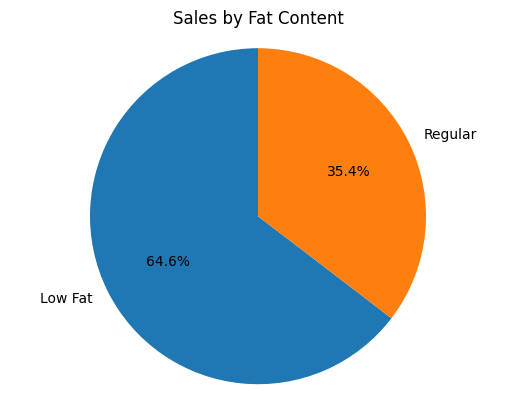

In [67]:
sales_by_fat=df.groupby("Item Fat Content")["Sales"].sum()
plt.pie(sales_by_fat,labels=sales_by_fat.index,autopct="%.1f%%",startangle=90)
plt.title("Sales by Fat Content")
plt.axis("equal")
plt.show()


Total Sales by Item Type

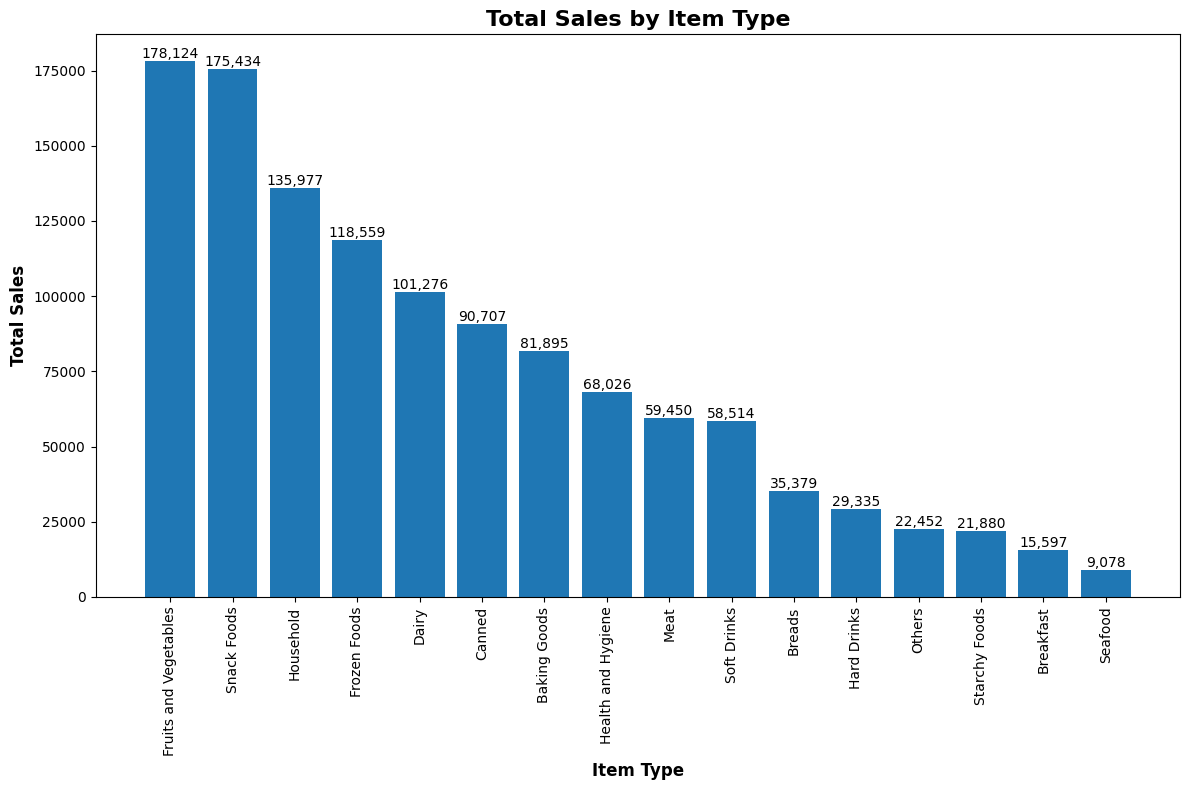

In [138]:
sales_by_type=df.groupby("Item Type")["Sales"].sum().sort_values(ascending=False)
plt.figure(figsize=(12,8))
bars=plt.bar(sales_by_type.index,sales_by_type.values) 

plt.xticks(rotation=90)
plt.xlabel("Item Type",fontsize=12,fontweight="bold")
plt.ylabel("Total Sales",fontsize=12,fontweight="bold")
plt.title("Total Sales by Item Type",fontsize=16,fontweight="bold")

for bar in bars:
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f'{bar.get_height():,.0f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

Fat Content by Outlet for Total Sales

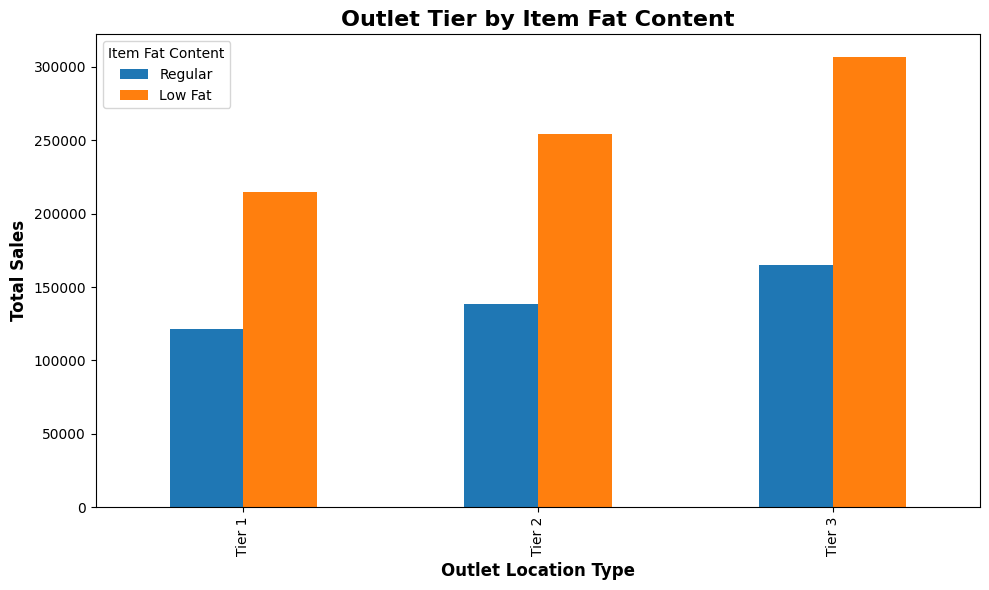

In [99]:
grouped=df.groupby(["Outlet Location Type","Item Fat Content"])["Sales"].sum().unstack()
grouped=grouped[["Regular","Low Fat"]]
grouped

grouped.plot(kind="bar",figsize=(10,6))
plt.xlabel("Outlet Location Type",fontsize=12,fontweight="bold")
plt.ylabel("Total Sales",fontsize=12,fontweight="bold")
plt.title("Outlet Tier by Item Fat Content",fontsize=16,fontweight="bold")
plt.tight_layout()
plt.show()

Total Sales by Outlet Establishment


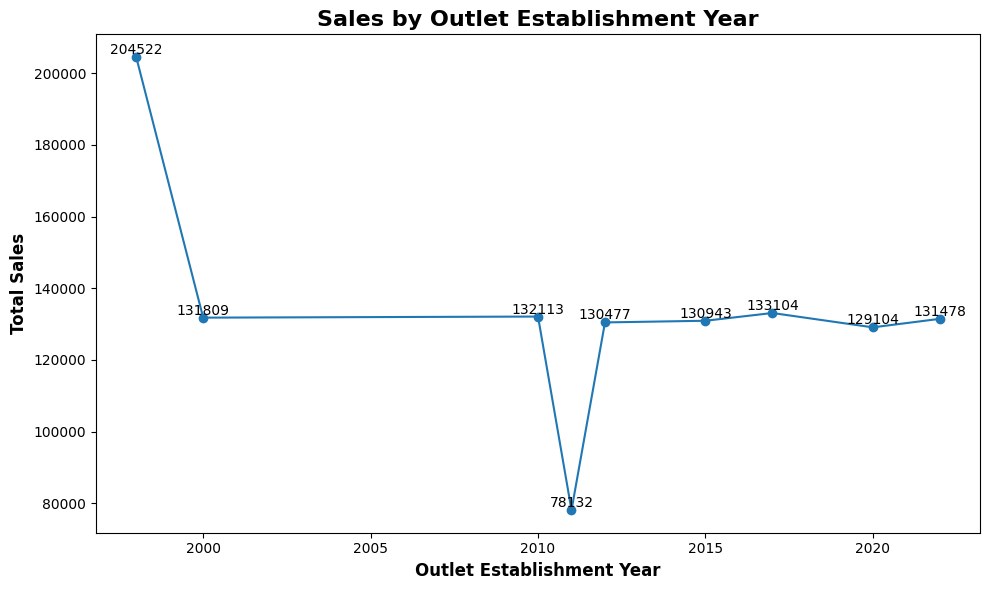

In [123]:
sales_by_year=df.groupby("Outlet Establishment Year")["Sales"].sum()
sales_by_year
plt.figure(figsize=(10,6))
plt.plot(sales_by_year.index,sales_by_year.values,marker="o")
plt.xlabel("Outlet Establishment Year",fontsize=12,fontweight="bold")
plt.ylabel("Total Sales",fontsize=12,fontweight="bold")
plt.title("Sales by Outlet Establishment Year",fontsize=16,fontweight="bold")

for x, y in zip(sales_by_year.index, sales_by_year.values):
    plt.text(x, y, f'{y:.0f}', ha='center', va='bottom')
plt.tight_layout()
plt.show()

Sales by outlet size

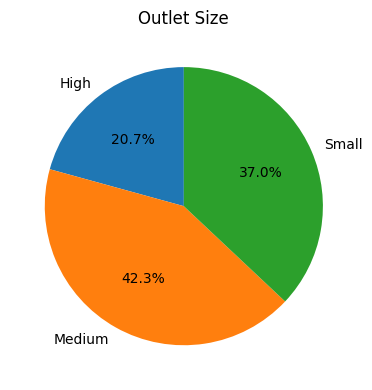

In [141]:
sales_by_size = df.groupby('Outlet Size')['Sales'].sum()

plt.figure(figsize=(4, 4))
plt.pie(sales_by_size, labels=sales_by_size.index, autopct='%1.1f%%', startangle=90)
plt.title('Outlet Size')
plt.tight_layout()
plt.show()

Sales by Outlet Location

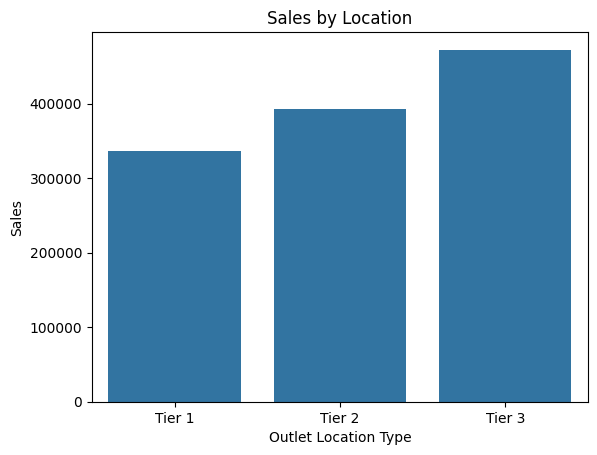

In [143]:
sales_by_location = df.groupby('Outlet Location Type')['Sales'].sum().reset_index()

sns.barplot(x='Outlet Location Type', y='Sales', data=sales_by_location)

plt.title("Sales by Location")
plt.show()